In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
print("Imported successfully")

Imported successfully


In [2]:
file_path = "../data/online_retail_II.xlsx"

In [3]:
excel_file = pd.ExcelFile(file_path)

In [4]:
excel_file.sheet_names

['Year 2009-2010', 'Year 2010-2011']

In [5]:
df_2009 = pd.read_excel(file_path, sheet_name="Year 2009-2010")
df_2010 = pd.read_excel(file_path, sheet_name="Year 2010-2011")

print("2009-2010:", df_2009.shape)
print("2010-2011:", df_2010.shape)

print("\n2009-2010 columns:")
print(df_2009.columns.tolist())

print("\n2010-2011 columns:")
print(df_2010.columns.tolist())

2009-2010: (525461, 8)
2010-2011: (541910, 8)

2009-2010 columns:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

2010-2011 columns:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [6]:
df_2009.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [7]:
df_2010.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [8]:
df_2009.info()

<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[us]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 32.1+ MB


In [9]:
df_2010.info()

<class 'pandas.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      541910 non-null  object        
 1   StockCode    541910 non-null  object        
 2   Description  540456 non-null  object        
 3   Quantity     541910 non-null  int64         
 4   InvoiceDate  541910 non-null  datetime64[us]
 5   Price        541910 non-null  float64       
 6   Customer ID  406830 non-null  float64       
 7   Country      541910 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [10]:
print("2009-2010")
display(df_2009[["Quantity", "Price"]].describe())
print("\n2010-2011")
display(df_2010[["Quantity", "Price"]].describe())

2009-2010


,Quantity,Price
count,525461.000000,525461.000000
mean,10.337667,4.688834
std,107.424110,146.126914
min,-9600.000000,-53594.360000
25%,1.000000,1.250000
50%,3.000000,2.100000
75%,10.000000,4.210000
max,19152.000000,25111.090000



2010-2011


,Quantity,Price
count,541910.000000,541910.000000
mean,9.552234,4.611138
std,218.080957,96.759765
min,-80995.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000


In [11]:
print("2009-2010")
print((df_2009["Quantity"] < 0).sum())
print((df_2009["Quantity"] > 0).sum())
print((df_2009["Quantity"] == 0).sum())
print("==============================")
print("2010-2011")
print((df_2010["Quantity"] < 0).sum())
print((df_2010["Quantity"] > 0).sum())
print((df_2010["Quantity"] == 0).sum())

2009-2010
12326
513135
0
2010-2011
10624
531286
0


In [12]:
negative_2009 = df_2009[df_2009["Quantity"] < 0]

negative_2009[["Invoice", "StockCode", "Description", "Quantity", "Price", "Customer ID"]].head(20)

,Invoice,StockCode,Description,Quantity,Price,Customer ID
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2.95,16321.0
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,1.65,16321.0
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,4.25,16321.0
181,C489449,21896,POTTING SHED TWINE,-6,2.10,16321.0
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2.95,16321.0
183,C489449,21871,SAVE THE PLANET MUG,-12,1.25,16321.0
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,1.25,16321.0
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,0.85,16321.0
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2.95,16321.0
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,4.25,17592.0


In [13]:
negative_2010 = df_2010[df_2010["Quantity"] < 0]

negative_2010[["Invoice", "StockCode", "Description", "Quantity", "Price", "Customer ID"]].head(20)

,Invoice,StockCode,Description,Quantity,Price,Customer ID
141,C536379,D,Discount,-1,27.50,14527.0
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,4.65,15311.0
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,1.65,17548.0
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,0.29,17548.0
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,0.29,17548.0
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,0.29,17548.0
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,3.45,17548.0
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,1.65,17548.0
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,1.65,17548.0
937,C536506,22960,JAM MAKING SET WITH JARS,-6,4.25,17897.0


In [14]:
df_2009["TotalAmount"] = df_2009["Quantity"] * df_2009["Price"]
df_2009.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [15]:
df_2010["TotalAmount"] = df_2010["Quantity"] * df_2010["Price"]
df_2010.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [16]:
print("2009 - 2010")
print("Sales", df_2009.loc[df_2009["Quantity"] > 0, "TotalAmount"].sum())
print("Cancellations" ,df_2009.loc[df_2009["Quantity"] < 0, "TotalAmount"].sum())

2009 - 2010
Sales 10169713.574000001
Cancellations -630228.9400000001


In [17]:
print("2010-2011")
print("Sales",df_2010.loc[df_2010["Quantity"] > 0, "TotalAmount"].sum())
print("Cancellations", df_2010.loc[df_2010["Quantity"] < 0, "TotalAmount"].sum())

2010-2011
Sales 10644578.423999999
Cancellations -896812.49


In [18]:
df_2009_clean = df_2009[df_2009["Quantity"] > 0]
df_2010_clean = df_2010[df_2010["Quantity"] > 0]

In [24]:
(df_2009_clean["Quantity"] < 0).sum()


np.int64(0)

In [25]:
(df_2010_clean["Quantity"] < 0).sum()

np.int64(0)

In [26]:
df = pd.concat([df_2009_clean, df_2010_clean], ignore_index=True)

In [27]:
df.shape

(1044421, 9)

In [28]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [29]:
df.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount
1044416,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
1044417,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
1044418,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
1044419,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France,14.85
1044420,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680.0,France,18.00


In [30]:
df['Customer ID'].isna().sum()

np.int64(238801)

In [31]:
df['Customer ID'].isna().mean() * 100

np.float64(22.86443876559357)

In [32]:
df['Customer ID'].nunique()

5881

In [33]:
df = df[df["Customer ID"].notna()].copy()

In [34]:
df.shape

(805620, 9)

In [35]:
df['Customer ID'].isna().sum()

np.int64(0)

In [36]:
#RFM baseline
print("Earliest transaction date:", df['InvoiceDate'].min())
print("Latest transaction date:", df['InvoiceDate'].max())

Earliest transaction date: 2009-12-01 07:45:00
Latest transaction date: 2011-12-09 12:50:00


In [37]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(reference_date)


2011-12-10 12:50:00


In [38]:
customer_last_purchase = df.groupby('Customer ID')['InvoiceDate'].max().reset_index()
customer_last_purchase.head()

,Customer ID,InvoiceDate
0,12346.0,2011-01-18 10:01:00
1,12347.0,2011-12-07 15:52:00
2,12348.0,2011-09-25 13:13:00
3,12349.0,2011-11-21 09:51:00
4,12350.0,2011-02-02 16:01:00


In [39]:
customer_last_purchase["Recency"] = (reference_date - customer_last_purchase['InvoiceDate']).dt.days
customer_last_purchase.head()

,Customer ID,InvoiceDate,Recency
0,12346.0,2011-01-18 10:01:00,326
1,12347.0,2011-12-07 15:52:00,2
2,12348.0,2011-09-25 13:13:00,75
3,12349.0,2011-11-21 09:51:00,19
4,12350.0,2011-02-02 16:01:00,310


In [40]:
customer_frequency = df.groupby('Customer ID')['Invoice'].nunique().reset_index(name='Frequency')
customer_frequency.head()

,Customer ID,Frequency
0,12346.0,12
1,12347.0,8
2,12348.0,5
3,12349.0,4
4,12350.0,1


In [42]:
df['TotalAmount'] = df['Quantity'] * df['Price']

In [43]:
customer_monetary = df.groupby('Customer ID')['TotalAmount'].sum().reset_index(name='Monetary')

In [44]:
rfm = (
    customer_last_purchase[['Customer ID', 'Recency']]
    .merge(customer_frequency, on='Customer ID')
    .merge(customer_monetary, on='Customer ID')
)

In [45]:
rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346.0,326,12,77556.46
1,12347.0,2,8,5633.32
2,12348.0,75,5,2019.40
3,12349.0,19,4,4428.69
4,12350.0,310,1,334.40


In [46]:
rfm.shape

(5881, 4)

In [47]:
rfm.describe()

,Customer ID,Recency,Frequency,Monetary
count,5881.000000,5881.000000,5881.000000,5881.000000
mean,15314.674205,201.457745,6.287196,3017.076888
std,1715.429759,209.474135,13.012879,14734.128619
min,12346.000000,1.000000,1.000000,0.000000
25%,13833.000000,26.000000,1.000000,347.800000
50%,15313.000000,96.000000,3.000000,897.620000
75%,16797.000000,380.000000,7.000000,2304.180000
max,18287.000000,739.000000,398.000000,608821.650000


In [48]:
rfm.isna().sum()

Customer ID    0
Recency        0
Frequency      0
Monetary       0
dtype: int64

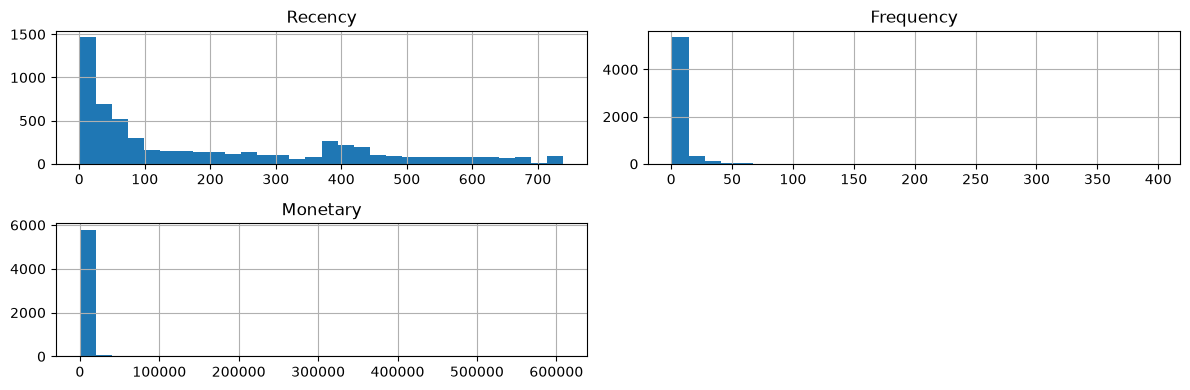

In [50]:
rfm[["Recency" , "Frequency" , "Monetary"]].hist(
    bins=30,
    figsize=(12, 4)
)
plt.tight_layout()
plt.show()

In [58]:
rfm[["Recency", "Frequency", "Monetary"]].skew()

Recency       0.886792
Frequency    12.653997
Monetary     25.320187
dtype: float64

In [57]:
rfm["Monetary_log"] = np.log1p(rfm["Monetary"])
rfm["Frequency_log"] = np.log1p(rfm["Frequency"])

In [60]:
rfm[["Recency", "Frequency_log", "Monetary_log"]].skew()

Recency          0.886792
Frequency_log    1.001904
Monetary_log     0.207893
dtype: float64

In [65]:
rfm.head()

,Customer ID,Recency,Frequency,Monetary,Monetary_log,Frequency_log
0,12346.0,326,12,77556.46,11.258774,2.564949
1,12347.0,2,8,5633.32,8.636632,2.197225
2,12348.0,75,5,2019.40,7.611051,1.791759
3,12349.0,19,4,4428.69,8.396085,1.609438
4,12350.0,310,1,334.40,5.815324,0.693147


In [63]:
features = ["Recency", "Frequency_log", "Monetary_log"]
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[features])

In [64]:
rfm_scaled = pd.DataFrame(rfm_scaled, columns=features, index=rfm.index)
rfm_scaled.head()

,Recency,Frequency_log,Monetary_log
0,0.594598,1.254938,3.170387
1,-0.952264,0.800635,1.291999
2,-0.603743,0.299705,0.557317
3,-0.871102,0.074457,1.119681
4,0.518209,-1.057568,-0.729063
